### Import libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.dummy import DummyClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

### Load the final processed data

Like Rohan's check, we'll do the same to make sure the work aligns. These will be identical to his to ensure consistency.

In [2]:
data_dir = Path("processed_data")

train_path = data_dir / "train_final.csv"
val_path = data_dir / "val_final.csv"
test_path = data_dir / "test_final.csv"

print("Train file exists:", train_path.exists())
print("Validation file exists:", val_path.exists())
print("Test file exists:", test_path.exists())


Train file exists: True
Validation file exists: True
Test file exists: True


In [3]:
train = pd.read_csv(train_path)
validation = pd.read_csv(val_path)

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)

train.head()

Train shape: (7746, 19)
Validation shape: (2584, 19)


,age,is_male,P_wave_duration_mean,P_wave_duration_std,PR_interval_mean,PR_interval_std,PR_segment_mean,PR_segment_std,QRS_duration_mean,QRS_duration_std,QT_interval_mean,QT_interval_std,ST_segment_mean,ST_segment_std,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_pNN50,target
0,-0.080067,-0.787935,-0.841006,-0.055135,1.089002,0.918455,1.332512,0.813291,-0.763211,-0.812053,0.201465,-0.630556,0.077558,-0.351457,0.946333,0.328705,-0.010365,1.386769,0
1,-1.191728,-0.787935,0.873540,-0.534451,0.366340,-0.757167,0.026520,-0.935958,-0.944048,-0.864915,0.020317,-0.806844,0.295670,-0.639444,0.672048,-0.043469,-0.208611,0.549509,0
2,-0.858230,1.269141,0.772142,-1.105336,0.294966,-0.833143,-0.003735,-0.984452,-0.775267,-0.795702,-0.018980,-0.771288,-0.039706,-0.865024,0.564292,-0.270677,-0.372043,-0.329613,0
3,0.753680,-0.787935,0.142246,-0.352941,-0.287922,-0.245758,-0.323090,-0.066711,0.534796,0.102527,0.171114,-0.353349,0.253455,0.068981,-0.308943,-0.508589,-0.483267,-0.706380,0
4,1.198344,1.269141,-0.687373,-0.249492,0.223592,-0.501063,0.461290,-0.524668,-0.413593,-0.444668,-1.675512,1.929814,-1.138082,2.036125,-0.123381,-0.196938,-0.380236,0.047154,0


In [4]:
print("Train columns:")
print(train.columns.tolist())

print("\nValidation columns:")
print(validation.columns.tolist())

Train columns:
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'target']

Validation columns:
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'target']


In [5]:
print("Train target counts:")
print(train["target"].value_counts().sort_index())

print("\nValidation target counts:")
print(validation["target"].value_counts().sort_index())

print("\nTrain positive rate:", round(train["target"].mean(), 3))
print("Validation positive rate:", round(validation["target"].mean(), 3))

Train target counts:
target
0    3885
1    3861
Name: count, dtype: int64

Validation target counts:
target
0    1291
1    1293
Name: count, dtype: int64

Train positive rate: 0.498
Validation positive rate: 0.5


In [6]:
drop_cols = ["target", "exam_id", "patient_id"]

feature_cols = [
    col for col in train.columns
    if col not in drop_cols
]

X_train = train[feature_cols]
y_train = train["target"]

X_val = validation[feature_cols]
y_val = validation["target"]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 18
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50']


Rohan's baseline gave us the following information:
{'model': 'Baseline',
 'C': nan,
 'accuracy': 0.4996130030959752,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': np.float64(0.5)}

In [7]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_val)
baseline_prob = baseline.predict_proba(X_val)[:, 1]

baseline_results = {
    "model": "Baseline",
    "accuracy": accuracy_score(y_val, baseline_pred),
    "precision": precision_score(y_val, baseline_pred, zero_division=0),
    "recall": recall_score(y_val, baseline_pred, zero_division=0),
    "f1": f1_score(y_val, baseline_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_val, baseline_prob)
}

baseline_results

{'model': 'Baseline',
 'accuracy': 0.4996130030959752,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5}

Using this, let's train a KNN model and see how it compares.

In [8]:
results = [baseline_results]

# neighbors
k_values = [5, 10, 15, 20, 25, 30, 35]

for k in k_values:
    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)
    prob = model.predict_proba(X_val)[:, 1]

    results.append({
        "model": "KNN",
        "n_neighbors": k,
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, prob)
    })

results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1,roc_auc,n_neighbors
0,Baseline,0.499613,0.000000,0.000000,0.000000,0.500000,NaN
1,KNN,0.618034,0.621815,0.604022,0.612789,0.658215,5.0
2,KNN,0.625774,0.656430,0.529002,0.585867,0.684374,10.0
3,KNN,0.645898,0.648585,0.638051,0.643275,0.698423,15.0
4,KNN,0.643189,0.662577,0.584687,0.621200,0.702498,20.0
5,KNN,0.639319,0.643368,0.626450,0.634796,0.709230,25.0
6,KNN,0.654025,0.670951,0.605568,0.636585,0.713849,30.0
7,KNN,0.648994,0.653662,0.634957,0.644174,0.714968,35.0


In [9]:
results_df.sort_values("roc_auc", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc,n_neighbors
7,KNN,0.648994,0.653662,0.634957,0.644174,0.714968,35.0
6,KNN,0.654025,0.670951,0.605568,0.636585,0.713849,30.0
5,KNN,0.639319,0.643368,0.626450,0.634796,0.709230,25.0
4,KNN,0.643189,0.662577,0.584687,0.621200,0.702498,20.0
3,KNN,0.645898,0.648585,0.638051,0.643275,0.698423,15.0
2,KNN,0.625774,0.656430,0.529002,0.585867,0.684374,10.0
1,KNN,0.618034,0.621815,0.604022,0.612789,0.658215,5.0
0,Baseline,0.499613,0.000000,0.000000,0.000000,0.500000,NaN


In [10]:
# Pick the KNN model with the best validation ROC-AUC.
knn_results = results_df[results_df["model"] == "KNN"].copy()

best_row = knn_results.sort_values("roc_auc", ascending=False).iloc[0]
best_k = best_row["n_neighbors"]

print("Best k:", best_k)
print(best_row)

Best k: 35.0
model               KNN
accuracy       0.648994
precision      0.653662
recall         0.634957
f1             0.644174
roc_auc        0.714968
n_neighbors        35.0
Name: 7, dtype: object


It's important to note here that although the model with the most neighbors has the highest ROC-AUC, the accuracy has begun to drop off between the 6th and 7th model.

In [11]:
# Pick the KNN model with the best validation accuracy.
knn_results = results_df[results_df["model"] == "KNN"].copy()

best_row = knn_results.sort_values("accuracy", ascending=False).iloc[0]
best_k = best_row["n_neighbors"]

print("Best k:", best_k)
print(best_row)

Best k: 30.0
model               KNN
accuracy       0.654025
precision      0.670951
recall         0.605568
f1             0.636585
roc_auc        0.713849
n_neighbors        30.0
Name: 6, dtype: object


In [12]:
best_model = KNeighborsClassifier(
    n_neighbors=int(best_k)
)

best_model.fit(X_train, y_train)

best_pred = best_model.predict(X_val)
best_prob = best_model.predict_proba(X_val)[:, 1]

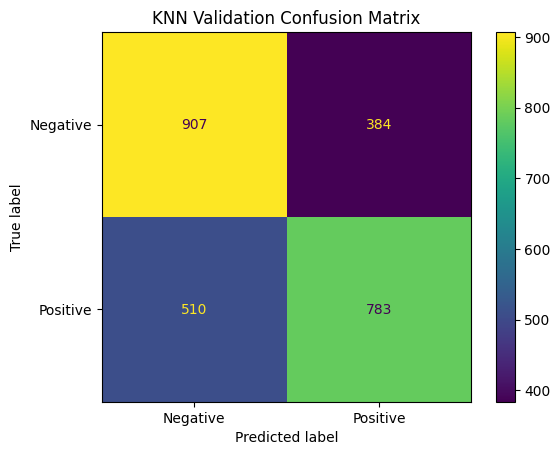

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    best_pred,
    display_labels=["Negative", "Positive"]
)

plt.title("KNN Validation Confusion Matrix")
plt.show()

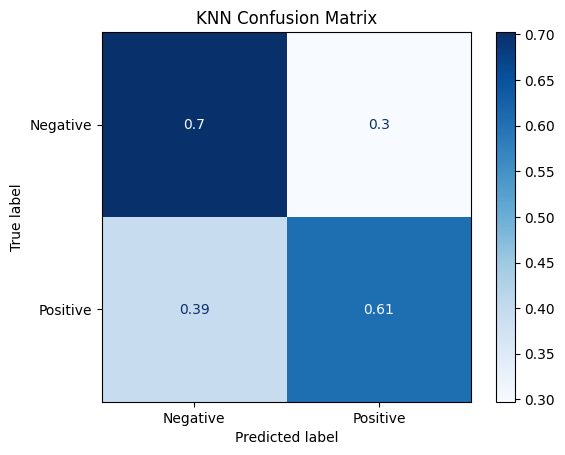

In [16]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    best_pred,
    cmap="Blues",
    normalize="true",
    display_labels=["Negative", "Positive"]
)

plt.title("KNN Confusion Matrix")
plt.show()

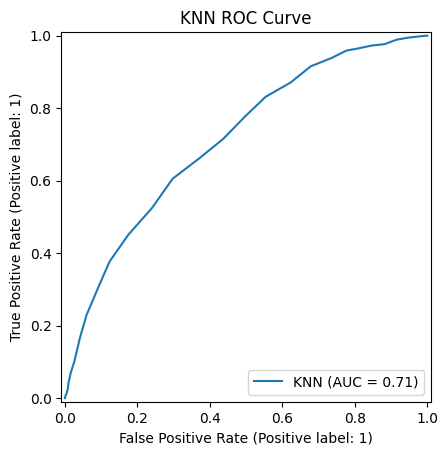

In [15]:
RocCurveDisplay.from_predictions(
    y_val, 
    best_prob, 
    name="KNN"
)
plt.title("KNN ROC Curve")
plt.show()

Unlike logistic regression, decision tree, or random forest, KNN doesn't put emphasis on a feature importance since it predicts based on distance between observations rather than feature weights. The next best thing was to check permutation performance to see which features contributed to its ROC-AUC score.

In [19]:
importance = permutation_importance(
    best_model,
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

knn_feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance.importances_mean
})

knn_feature_importance = knn_feature_importance.sort_values(
    "importance",
    ascending=False
)

knn_feature_importance.head(10)

,feature,importance
0,age,0.033236
12,ST_segment_mean,0.025322
10,QT_interval_mean,0.014819
6,PR_segment_mean,0.010376
2,P_wave_duration_mean,0.010134
8,QRS_duration_mean,0.008916
3,P_wave_duration_std,0.007831
14,HRV_MeanNN,0.007726
13,ST_segment_std,0.007098
4,PR_interval_mean,0.006821


In [20]:
results_dir = Path("model_results")
results_dir.mkdir(exist_ok=True)

results_df.to_csv(results_dir / "knn_results.csv", index=False)

knn_feature_importance.to_csv(results_dir / "knn_permutation_importance.csv", index=False)
print("Saved KNN results and permutation importance to model_results/")

Saved KNN results and permutation importance to model_results/
